**Assignment - DT**     - **TITANIC**

*Name: Alisha Khan*

*Batch-II*

* Note: For NULL values Summary --> df.isnull().sum()

Apply Decision Tree, classification algorithm to predict "Survived".

PassengerId: Unique ID for each passenger
Survived: Target label indicating outcome: 0 = did not survive, 1 = survived.
Pclass: Ticket class (a proxy for socio-economic status): 1 = 1st class, 2 = 2nd class, 3 = 3rd class.
Name: Passenger’s full name (often includes title like Mr, Mrs, Miss, etc.).
Gender: Passenger’s gender (typically male / female).
Age: Passenger age in years (may contain missing values).
SibSp: Number of siblings/spouses aboard the Titanic (traveling with the passenger).
Parch: Number of parents/children aboard the Titanic (traveling with the passenger).
Ticket: Ticket number/string (identifier for the ticket).
Fare: Amount paid for the ticket (in the dataset’s currency units).
Cabin: Cabin number/identifier (may be missing for many passengers).
Embarked: Port where the passenger boarded the ship: C = Cherbourg, Q = Queenstown, S = Southampton

In [ ]:
# for data handling
import pandas as pd
import numpy as np

In [ ]:
# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("/content/Data01.csv")     # load dataset

In [ ]:
df.head() # initial 5 rows

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# check null values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# handling missing values
df['Age'].fillna(df['Age'].mean())       # simple imputation ( Mean Imputation )
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])  # simple imputation (mode)
df = df.drop(columns=['Cabin'])

In [ ]:
# dropping irrelevant columns
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [ ]:
# convert categorical into numeric
df["Gender"] = df['Gender'].map({"male": 0, "female": 1})  # here we convert genders into numbers (Label Encoding)

df = pd.get_dummies(df, columns = ['Embarked'], drop_first=True)  # we convert embarked to dummy variable (One-Hot Encoding)

In [ ]:
# working on features and target

# x = features (independent variable)
X = df.drop(columns=['Survived'])

# y = target variable (dependent)
y = df['Survived']

In [ ]:
# train_test_split
# here we divide data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Applying decision tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# here we predict by test data
y_pred = model.predict(X_test)

In [ ]:
# evaluation
# we check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# detailed report
from sklearn.metrics import accuracy_score, classification_report
print(classification_report(y_test, y_pred))

Accuracy: 0.7988826815642458
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



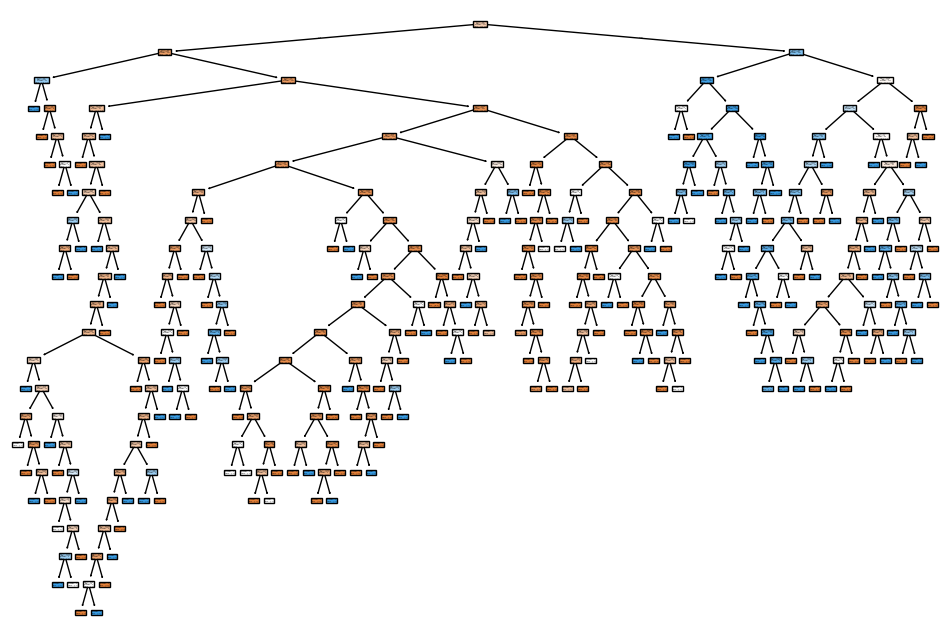

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(model, filled=True)
plt.show()

In [ ]:
print(df.columns)

Index(['Survived', 'Pclass', 'Gender', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [ ]:
print(df.head())
print(df.info())

   Survived  Pclass  Gender   Age  SibSp  Parch     Fare  Embarked_Q  \
0         0       3       0  22.0      1      0   7.2500       False   
1         1       1       1  38.0      1      0  71.2833       False   
2         1       3       1  26.0      0      0   7.9250       False   
3         1       1       1  35.0      1      0  53.1000       False   
4         0       3       0  35.0      0      0   8.0500       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Gender      891 non-null    int64  
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float6